<a href="https://colab.research.google.com/github/crypt0d1v3r/CannyValley/blob/JakeTest/TestingModel_Git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Install dependencies for pulling datasets
%pip install kagglehub
%pip install datasets
%pip install torch
%pip install torchvision
%pip install numpy
%pip install matplotlib

In [9]:
import kagglehub
from datasets import load_dataset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models # Import models

# We will use a pre-trained ResNet18 instead of a custom CNN
def get_pretrained_model():
    # Load pre-trained ResNet18
    model = models.resnet18(pretrained=True)

    # Freeze all layers (optional, but good for small datasets to prevent overfitting)
    # for param in model.parameters():
    #     param.requires_grad = False

    # Replace the final fully connected layer
    # ResNet18's fc layer has 512 input features
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, 2) # 2 output classes
    return model

class CNN(torch.nn.Module):
  def __init__(self):
      super().__init__()
      self.model = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=32,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=32, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=64, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Flatten(),
          torch.nn.Linear(64 * 28 * 28, 512),
          torch.nn.ReLU(),
          torch.nn.Linear(512, 2)
      )

  def forward(self, x):
      return self.model(x)

In [10]:
dataset_path = "./datasets"
dataset_options = [
    "birdy654/cifake-real-and-ai-generated-synthetic-images",
    "Hemg/AI-vs-Real-images",
    "bitmind/AI-vs-Real-Dataset-Images-Proper"
]

print("Please choose a dataset from the following options:")
for i, option in enumerate(dataset_options):
    print(f"{i+1}. {option}")

while True:
    try:
        choice = int(input("Enter the number corresponding to your choice: "))
        if 1 <= choice <= len(dataset_options):
            dataset_source = dataset_options[choice - 1]
            break
        else:
            print("Invalid choice. Please enter a number from the list.")
    except ValueError:
        print("Invalid input. Please enter a number.")

if dataset_source == "birdy654/cifake-real-and-ai-generated-synthetic-images":
  dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
elif dataset_source == "Hemg/AI-vs-Real-images":
  dataset_path = load_dataset("Hemg/AI-vs-Real-images")
elif dataset_source == "bitmind/AI-vs-Real-Dataset-Images-Proper":
  dataset_path = load_dataset("bitmind/AI-vs-Real-Dataset-Images-Proper")
else:
  raise Exception(f"Dataset Source {dataset_source} Unknown")

Please choose a dataset from the following options:
1. birdy654/cifake-real-and-ai-generated-synthetic-images
2. Hemg/AI-vs-Real-images
3. bitmind/AI-vs-Real-Dataset-Images-Proper
Enter the number corresponding to your choice: 2


Can choose from the following datasets

birdy654/cifake-real-and-ai-generated-synthetic-images  
Hemg/AI-vs-Real-images  
bitmind/AI-vs-Real-Dataset-Images-Proper

In [11]:
from torch.utils.data import Dataset as TorchDataset

class HuggingFaceDatasetWrapper(TorchDataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image']
        # Ensure image is RGB
        if image.mode != 'RGB':
            image = image.convert('RGB')

        label = item['label']
        if self.transform:
            image = self.transform(image)
        return image, label

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Check if dataset_path is a DatasetDict (from HuggingFace datasets) or a string (from KaggleHub)
if isinstance(dataset_path, dict): # DatasetDict is a dictionary-like object
    print("Loading dataset from Hugging Face DatasetDict...")
    if 'train' not in dataset_path:
        raise ValueError("Hugging Face DatasetDict must contain a 'train' split.")

    train_hf_dataset = dataset_path['train']
    test_hf_dataset = None

    if 'test' in dataset_path:
        test_hf_dataset = dataset_path['test']
        print("Using 'train' and 'test' splits from Hugging Face dataset.")
    elif 'validation' in dataset_path:
        test_hf_dataset = dataset_path['validation'] # Use validation as test if no test split
        print("Using 'train' and 'validation' splits from Hugging Face dataset (validation as test)."
             )
    else:
        # If no test or validation split, create one from the training set
        print("No 'test' or 'validation' split found. Creating a test split from the 'train' dataset.")
        # Ensure the dataset has a train_test_split method, which HuggingFace datasets typically do
        split_datasets = train_hf_dataset.train_test_split(test_size=0.2, seed=42)
        train_hf_dataset = split_datasets['train']
        test_hf_dataset = split_datasets['test']

    train_dataset = HuggingFaceDatasetWrapper(train_hf_dataset, transform=data_transforms)
    test_dataset = HuggingFaceDatasetWrapper(test_hf_dataset, transform=data_transforms)

    # Extract class names from Hugging Face dataset features if available
    if 'label' in dataset_path['train'].features and hasattr(dataset_path['train'].features['label'], 'names'):
        class_names = dataset_path['train'].features['label'].names
    else:
        # Fallback if names are not directly available, assume 0 for FAKE, 1 for REAL
        class_names = ['FAKE', 'REAL'] # Adjust based on actual dataset labels if known
else: # Assume it's a string path for ImageFolder (from KaggleHub)
    print("Loading dataset from local directory using ImageFolder...")
    train_dir = os.path.join(dataset_path, 'train')
    test_dir = os.path.join(dataset_path , 'test')

    train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)
    class_names = train_dataset.classes

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get class names (already set in the if/else block)
print(f"Classes: {class_names}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Use the new function to get the model
model = get_pretrained_model().to(device)
# model = CNN().to(device) # Original custom CNN model

Loading dataset from Hugging Face DatasetDict...
No 'test' or 'validation' split found. Creating a test split from the 'train' dataset.
Classes: ['Fake', 'Real']
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


In [12]:
import os
import glob
from google.colab import files

# Find all .pth files in the current directory
pth_files = glob.glob("*.pth")

print("Please choose a model file:")
for i, f in enumerate(pth_files):
    print(f"{i+1}. {f}")
print(f"{len(pth_files)+1}. Upload a new model file")

model_file_path = None

while True:
    try:
        choice = int(input("Enter the number corresponding to your choice: "))
        if 1 <= choice <= len(pth_files):
            model_file_path = pth_files[choice - 1]
            break
        elif choice == len(pth_files) + 1:
            print("Please upload your model file (.pth)...")
            uploaded = files.upload()
            if not uploaded:
                print("No file uploaded. Please try again.")
                continue
            # Assume the user uploads one file, take the first key
            model_file_path = list(uploaded.keys())[0]
            break
        else:
             print("Invalid choice. Please enter a number from the list.")
    except ValueError:
        print("Invalid input. Please enter a number.")

print(f"Using model file: {model_file_path}")

# Re-instantiate the model with the correct architecture using the helper function
model = get_pretrained_model().to(device)
model.load_state_dict(torch.load(model_file_path)) # Load the state dictionary
model.eval() # Set the model to evaluation mode
print("Model loaded successfully!")

# model = CNN().to(device) # Re-instantiate the model with the correct architecture

Please choose a model file:
1. cnn_model_Hemg_TransferLearn.pth
2. Upload a new model file
Enter the number corresponding to your choice: 1
Using model file: cnn_model_Hemg_TransferLearn.pth
Model loaded successfully!


Test set accuracy = 47.2025774005972 %


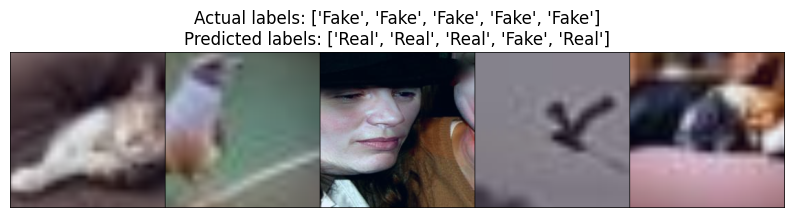

In [37]:
test_acc = 0
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

# Visualize some predictions by sampling randomly from the entire test_dataset
num_images = 5 # Number of images to display

# Generate random indices from the entire test_dataset
random_indices = np.random.choice(len(test_dataset), num_images, replace=False)

# Collect the images and their true labels for display
display_images = []
display_true_labels = []
for idx in random_indices:
    # Convert numpy int64 to python int to avoid TypeError with Hugging Face datasets
    idx = int(idx)
    image, label = test_dataset[idx]
    display_images.append(image)
    display_true_labels.append(label)

# Convert to a batch tensor and move to device for prediction
display_images_tensor = torch.stack(display_images).to(device)

# Get predictions for the randomly selected images
model.eval()
with torch.no_grad():
    outputs = model(display_images_tensor)
    _, display_pred_labels = torch.max(outputs.data, 1)

# Get true and predicted labels as names
y_true_name = [class_names[label] for label in display_true_labels]
y_pred_name = [class_names[label.item()] for label in display_pred_labels]

title = f"Actual labels: {y_true_name}\nPredicted labels: {y_pred_name}"

plt.figure(figsize=(10, 5))
plt.imshow(np.transpose(torchvision.utils.make_grid(display_images_tensor.cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()

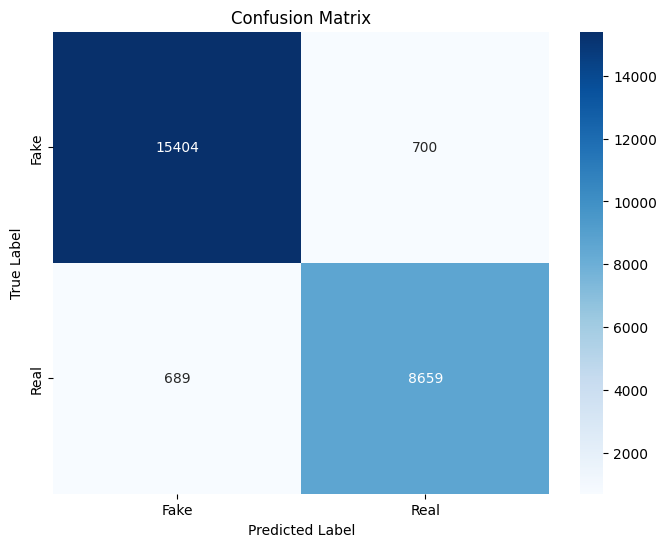

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to store true and predicted labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Classify a new image interactively

To classify a new image, you can upload it using the code below or specify a path to an existing image file. The model will then preprocess the image and predict whether it's 'FAKE' or 'REAL'.

In [31]:
from google.colab import files
from PIL import Image

# Upload an image file
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  image_path = fn

# If you prefer to use an existing image on disk, you can set image_path directly:
# image_path = "path/to/your/image.jpg"

Saving ai_truck.jpg to ai_truck.jpg
User uploaded file "ai_truck.jpg" with length 151648 bytes


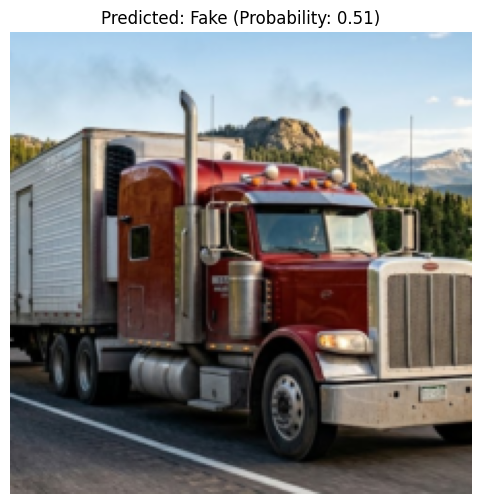

Class Probabilities:
  Fake: 0.5099
  Real: 0.4901
The model predicts this image is: Fake with probability 0.51


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms

# Function to classify a single image
def classify_image(image_path, model, transforms, class_names, device):
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply transformations
    input_tensor = transforms(image)

    # Add batch dimension and move to device
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output, dim=1)[0] # Get probabilities for the single image
        _, predicted_class_idx = torch.max(probabilities, 0) # Use 0 for a single tensor

    predicted_class_name = class_names[predicted_class_idx.item()]
    predicted_probability = probabilities[predicted_class_idx.item()].item()

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    # Denormalize the tensor for display
    display_image_tensor = input_tensor.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    display_image_tensor = display_image_tensor * std + mean
    # Ensure values are in [0, 1] range for imshow and convert to numpy array
    display_image_tensor = torch.clamp(display_image_tensor, 0, 1)
    plt.imshow(display_image_tensor.numpy().transpose((1, 2, 0)))
    plt.title(f"Predicted: {predicted_class_name} (Probability: {predicted_probability:.2f})")
    plt.axis('off')
    plt.show()

    # Print all class probabilities
    print("Class Probabilities:")
    for i, prob in enumerate(probabilities):
        print(f"  {class_names[i]}: {prob.item():.4f}")

    return predicted_class_name, predicted_probability

# We removed the redundant model definition and loading here.
# The code now relies on the 'model' object loaded in previous cells.

# Define data_transforms specific for this visualization
# Added an initial Resize to 64x64 to simulate lower resolution, then resize up
data_transforms_viz = transforms.Compose([
    #transforms.Resize(32),  # Downsample to simulate low resolution (even lower)
    transforms.Resize(256), # Then upscale for model input size, making it blurry
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Assuming class_names is ['FAKE', 'REAL'] from previous execution
# If not, it would need to be re-defined here as well for robustness
if 'class_names' not in locals():
    class_names = ['FAKE', 'REAL'] # Explicitly define for robustness

# Classify the uploaded image
# The image_path variable is set by the previous cell (0943dcbc) after file upload
if 'image_path' in locals():
    predicted_class, probability = classify_image(image_path, model, data_transforms_viz, class_names, device)
    print(f"The model predicts this image is: {predicted_class} with probability {probability:.2f}")
else:
    print("Error: image_path is not defined. Please run the cell above to upload an image.")

Prediction: Real
Confidence: 0.5051 (50.51%)
Raw Probabilities: Fake: 0.4949, Real: 0.5051


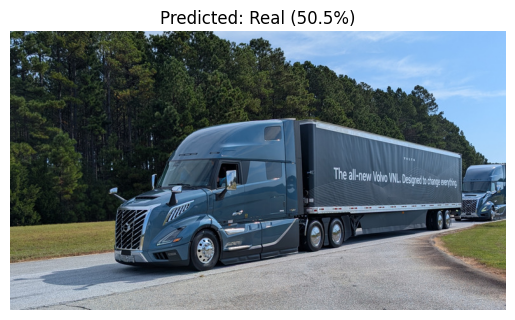

In [35]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path, model, transform, class_names, device):
    # 1. Load the image
    try:
        img = Image.open(image_path).convert('RGB') # Ensure RGB
    except FileNotFoundError:
        print(f"Error: Could not find image at {image_path}")
        return

    # 2. Apply the SAME transforms as training
    # (Resize, CenterCrop, RGB conversion, Normalize)
    img_t = transform(img)

    # 3. Add batch dimension (Model expects [Batch, Channel, Height, Width])
    batch_t = torch.unsqueeze(img_t, 0).to(device)

    # 4. Set model to evaluation mode
    model.eval()

    # 5. Inference
    with torch.no_grad():
        output = model(batch_t)

        # 6. Apply Softmax to get probabilities (0 to 1)
        probs = F.softmax(output, dim=1)

        # Get the top prediction
        conf, predicted = torch.max(probs, 1)

    # Result
    predicted_class = class_names[predicted.item()]
    confidence = conf.item()

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

    # Print probabilities for all classes dynamically
    prob_str = "Raw Probabilities: "
    for i, name in enumerate(class_names):
        prob_str += f"{name}: {probs[0][i]:.4f}, "
    print(prob_str.strip(', '))

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.1f}%)")
    plt.show()

# Example usage:
# Upload an image to the files tab on the left, then replace 'test_image.jpg' below
predict_image('truck.jpg', model, data_transforms, class_names, device)

In [36]:
# Sanity Check: Check predictions on the training set
# If the model was trained, it should perform well on the training data.

print("Checking model performance on a batch from the training set...")
model.eval()

# Get a batch of training data
try:
    images, labels = next(iter(train_loader))
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

    # Calculate accuracy for this batch
    batch_acc = (preds == labels).sum().item() / len(labels)
    print(f"Training Batch Accuracy: {batch_acc * 100:.2f}%")

    # Show first 5 predictions and probabilities
    print("\nSample Predictions (Training Set):")
    for i in range(5):
        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]
        confidence = probs[i][preds[i].item()].item()
        print(f"  Image {i+1}: True: {true_label}, Pred: {pred_label}, Conf: {confidence:.4f}")

except Exception as e:
    print(f"Error during sanity check: {e}")

Checking model performance on a batch from the training set...
Training Batch Accuracy: 50.00%

Sample Predictions (Training Set):
  Image 1: True: Fake, Pred: Real, Conf: 0.5101
  Image 2: True: Fake, Pred: Fake, Conf: 0.5092
  Image 3: True: Fake, Pred: Real, Conf: 0.5047
  Image 4: True: Fake, Pred: Real, Conf: 0.5119
  Image 5: True: Fake, Pred: Real, Conf: 0.5022


In [ ]:
import torch.optim as optim
from tqdm import tqdm

# define training function
def train_model(model, train_loader, criterion, optimizer, num_epochs=3):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Progress bar
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward + backward + optimize
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar
            progress_bar.set_postfix({'loss': running_loss / (total / labels.size(0)), 'acc': 100 * correct / total})

    print('Finished Training')

# Set up Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
print("Starting training... (This may take a few minutes)")
train_model(model, train_loader, criterion, optimizer, num_epochs=3)

# Save the newly trained model
torch.save(model.state_dict(), 'new_trained_resnet18.pth')
print("New model saved as 'new_trained_resnet18.pth'")